# Model Training
- 1: Define 5 models
- 2: Train with multiple seeds
- 3: Hypothesis testing
- 4: Hyperparameter tuning
- 5: Final model selection
- 6: Test set evaluation


# Step 0: Import Lib and data

In [10]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Model Selection & Evaluation
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# Sklearn - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Statistical testing
from scipy import stats

# SMOTE for handling class imbalance
from imblearn.over_sampling import SMOTE





In [11]:
# Define paths
artifact_path = Path("preprocessing_artifacts")

print("=" * 80)
print("LOADING PREPROCESSED DATA")
print("=" * 80)

# ============================================
# CONFIGURATION: FEATURE FILTERING
# ============================================
USE_FEATURE_FILTERING = True  # Set to False to use all features

print(f"\n⚙️  CONFIGURATION:")
print(f"   Feature Filtering: {'ENABLED' if USE_FEATURE_FILTERING else 'DISABLED'}")

# Define feature columns to use (only used if filtering is enabled)
audio_features_cols = ['Speechiness', 'Danceability', 'Valence', 'Loudness_norm']
artist_features_cols = ['artist_song_count', 
                        'artist_avg_rank',
                        'artist_best_rank']

temporal_features_cols = ['is_friday_release']

# Combine all selected features
selected_features = audio_features_cols + artist_features_cols + temporal_features_cols

if USE_FEATURE_FILTERING:
    print(f"\n📋 Selected Features ({len(selected_features)} total):")
    print(f"   Audio Features ({len(audio_features_cols)}): {audio_features_cols}")
    print(f"   Artist Features ({len(artist_features_cols)}): {artist_features_cols}")
    print(f"   Temporal Features ({len(temporal_features_cols)}): {temporal_features_cols}")

# Load Baseline (Scaled) data
X_train_baseline_full = pd.read_csv(artifact_path / "X_train_baseline.csv")
X_val_baseline_full = pd.read_csv(artifact_path / "X_val_baseline.csv")

# Apply filtering based on configuration
if USE_FEATURE_FILTERING:
    # Filter to only selected features
    X_train_baseline = X_train_baseline_full[selected_features]
    X_val_baseline = X_val_baseline_full[selected_features]
    
    # Verify all selected features are present
    missing_features = set(selected_features) - set(X_train_baseline.columns)
    if missing_features:
        print(f"\n⚠️  WARNING: Missing features in baseline: {missing_features}")
    else:
        print(f"\n✅ All {len(selected_features)} selected features found and filtered")
else:
    # Use all features
    X_train_baseline = X_train_baseline_full.copy()
    X_val_baseline = X_val_baseline_full.copy()
    print(f"\n✅ Using all {X_train_baseline.shape[1]} features (no filtering)")

# Load L1 Selected Features data
X_train_L1 = pd.read_csv(artifact_path / "X_train_L1.csv")
X_val_L1 = pd.read_csv(artifact_path / "X_val_L1.csv")

# Load PCA data
X_train_pca = pd.read_csv(artifact_path / "X_train_pca.csv")
X_val_pca = pd.read_csv(artifact_path / "X_val_pca.csv")

# Load target variables
y_train = pd.read_csv(artifact_path / "y_train.csv")
y_val = pd.read_csv(artifact_path / "y_val.csv")

# Convert target to binary (if not already)
y_train_array = y_train['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values
y_val_array = y_val['popularity_label'].map({'Popular': 1, 'Not Popular': 0}).values

print("\n✅ Data loaded successfully!\n")
print(f"Baseline {'(filtered)' if USE_FEATURE_FILTERING else '(all features)'}: X_train={X_train_baseline.shape}, X_val={X_val_baseline.shape}")
print(f"L1 Selection:        X_train={X_train_L1.shape}, X_val={X_val_L1.shape}")
print(f"PCA:                 X_train={X_train_pca.shape}, X_val={X_val_pca.shape}")
print(f"Target:              y_train={y_train_array.shape}, y_val={y_val_array.shape}")

print("\nClass distribution:")
print(f"  Training:   {np.bincount(y_train_array)}")
print(f"  Validation: {np.bincount(y_val_array)}")

print("=" * 80)

LOADING PREPROCESSED DATA

⚙️  CONFIGURATION:
   Feature Filtering: ENABLED

📋 Selected Features (8 total):
   Audio Features (4): ['Speechiness', 'Danceability', 'Valence', 'Loudness_norm']
   Artist Features (3): ['artist_song_count', 'artist_avg_rank', 'artist_best_rank']
   Temporal Features (1): ['is_friday_release']

✅ All 8 selected features found and filtered

✅ Data loaded successfully!

Baseline (filtered): X_train=(6158, 8), X_val=(1414, 8)
L1 Selection:        X_train=(6158, 10), X_val=(1414, 10)
PCA:                 X_train=(6158, 13), X_val=(1414, 13)
Target:              y_train=(6158,), y_val=(1414,)

Class distribution:
  Training:   [4310 1848]
  Validation: [1015  399]


In [12]:
# Create SMOTE-resampled versions with different variable names to preserve original data
smote = SMOTE(random_state=42, sampling_strategy='auto')

# SMOTE for Baseline
X_train_baseline_smote, y_train_baseline_smote = smote.fit_resample(X_train_baseline, y_train_array)
print(f"Baseline SMOTE - Original: {X_train_baseline.shape}, After SMOTE: {X_train_baseline_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_baseline_smote)}")

# SMOTE for L1
X_train_L1_smote, y_train_L1_smote = smote.fit_resample(X_train_L1, y_train_array)
print(f"\nL1 SMOTE - Original: {X_train_L1.shape}, After SMOTE: {X_train_L1_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_L1_smote)}")

# SMOTE for PCA
X_train_pca_smote, y_train_pca_smote = smote.fit_resample(X_train_pca, y_train_array)
print(f"\nPCA SMOTE - Original: {X_train_pca.shape}, After SMOTE: {X_train_pca_smote.shape}")
print(f"  Class distribution: {np.bincount(y_train_pca_smote)}")

# Create a dictionary for SMOTE datasets (for later use)
datasets_smote = {
    'Baseline': (X_train_baseline_smote, X_val_baseline, y_train_baseline_smote),
    'L1': (X_train_L1_smote, X_val_L1, y_train_L1_smote),
    'PCA': (X_train_pca_smote, X_val_pca, y_train_pca_smote)
}

print("\n✅ SMOTE applied successfully to all preprocessing methods!")

Baseline SMOTE - Original: (6158, 8), After SMOTE: (8620, 8)
  Class distribution: [4310 4310]

L1 SMOTE - Original: (6158, 10), After SMOTE: (8620, 10)
  Class distribution: [4310 4310]

PCA SMOTE - Original: (6158, 13), After SMOTE: (8620, 13)
  Class distribution: [4310 4310]

✅ SMOTE applied successfully to all preprocessing methods!


## Step 1: Define Models

In [13]:
def get_models():
    """
    Define all models with L2 regularization parameters.
    Returns a dictionary of model_name: model_instance
    """
    models = {
        # 1. Logistic Regression with L2 regularization
        'Logistic Regression': LogisticRegression(
            max_iter=500,
            class_weight='balanced',
            random_state=42,
            penalty='l2',        # L2 regularization (Ridge)
            C=1.0,               # Inverse regularization strength (smaller = stronger L2)
            solver='lbfgs'       # Best solver for L2
        ),
        
        # 2. SVM - Linear Kernel with L2 regularization (OPTIMIZED)
        'SVM (Linear)': SVC(
            kernel='linear',
            class_weight='balanced',
            random_state=42,
            probability=True,
            max_iter=1000,
            cache_size=500,
            C=1.0                # Regularization parameter (smaller = stronger L2)
        ),
        
        # 3. SVM - RBF Kernel with L2 regularization (OPTIMIZED)
        'SVM (RBF)': SVC(
            kernel='rbf',
            class_weight='balanced',
            random_state=42,
            probability=True,
            max_iter=1000,
            cache_size=500,
            gamma='scale',
            C=1.0                # Regularization parameter (smaller = stronger L2)
        ),
        
        # 4. Random Forest with regularization parameters
        'Random Forest': RandomForestClassifier(
            n_estimators=50,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1,
            max_depth=10,        # Limit tree depth (regularization)
            min_samples_split=5, # Min samples to split node
            min_samples_leaf=2   # Min samples in leaf node
        ),
        
        # 5. Gradient Boosting with regularization
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=50,
            random_state=42,
            learning_rate=0.1,   # Lower = more regularization
            max_depth=3,         # Limit tree depth
            min_samples_split=5,
            min_samples_leaf=2,
            subsample=0.8        # Use 80% of samples per tree (regularization)
        ),
        
        # 6. XGBoost with L2 regularization
        'XGBoost': XGBClassifier(
            n_estimators=100,
            random_state=42,
            eval_metric='logloss',
            use_label_encoder=False,
            n_jobs=-1,
            learning_rate=0.1,
            max_depth=6,
            reg_lambda=1.0,      # L2 regularization (default=1, increase for stronger)
            reg_alpha=0,         # L1 regularization (set to 0 for pure L2)
            subsample=0.8,
            colsample_bytree=0.8
        )
    }
    
    return models

## Step 2: Train model with different seeds

In [14]:
# Add this cell BEFORE "STEP 2B: TRAIN MODELS WITH SMOTE DATA"

def train_and_evaluate(X_train, X_val, y_train, y_val, model, model_name, seed):
    """
    Train a model and evaluate it on training and validation sets.
    
    Parameters:
    -----------
    X_train : array-like
        Training features
    X_val : array-like
        Validation features
    y_train : array-like
        Training labels
    y_val : array-like
        Validation labels
    model : sklearn estimator
        Model to train
    model_name : str
        Name of the model
    seed : int
        Random seed (for tracking)
    
    Returns:
    --------
    dict : Dictionary containing all metrics
    """
    # Train the model
    model.fit(X_train, y_train)
    
    # Training predictions
    y_train_pred = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)
    
    # Validation predictions
    y_val_pred = model.predict(X_val)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    
    # ROC-AUC (if model supports predict_proba)
    try:
        y_val_proba = model.predict_proba(X_val)[:, 1]
        val_roc_auc = roc_auc_score(y_val, y_val_proba)
    except:
        val_roc_auc = None
    
    # Return results
    return {
        'model_name': model_name,
        'seed': seed,
        'train_acc': train_acc,
        'train_f1': train_f1,
        'val_acc': val_acc,
        'val_f1': val_f1,
        'val_precision': val_precision,
        'val_recall': val_recall,
        'val_roc_auc': val_roc_auc,
        'model': model  # Store trained model
    }

print("✅ train_and_evaluate function defined!")

✅ train_and_evaluate function defined!


In [15]:
# ============================================================================
# STEP 2B: TRAIN MODELS WITH SMOTE DATA (SINGLE SEED)
# ============================================================================

print("=" * 80)
print("TRAINING MODELS WITH SMOTE DATA (SINGLE SEED)")
print("=" * 80)

# Define single random seed
random_seed = 42

# Store results for SMOTE
results_smote = {
    'Baseline': [],
    'L1': [],
    'PCA': [],
    
}
# Get models dictionary
models = get_models()
print(f"\nTraining {len(models)} models × 1 seed × {len(datasets_smote)} preprocessing methods (SMOTE Data)")
print(f"Total runs: {len(models) * len(datasets_smote)}\n")
print("-" * 80)

# Train all models with SMOTE data
for preprocessing_name, (X_train_prep, X_val_prep, y_train_prep) in datasets_smote.items():
    print(f"\n📊 PREPROCESSING: {preprocessing_name} (SMOTE)")
    print(f"    Training samples: {X_train_prep.shape[0]}")
    print(f"    Features: {X_train_prep.shape[1]}")
    print(f"    Class distribution: {np.bincount(y_train_prep)}")
    print("-" * 80)
    
    for model_name, model in models.items():
        print(f"\n  🔹 Training: {model_name}")
        
        # Get a fresh copy of the model
        model_copy = get_models()[model_name]
        
        # Train and evaluate
        result = train_and_evaluate(
            X_train_prep, X_val_prep, 
            y_train_prep, y_val_array,
            model_copy, model_name, random_seed
        )
        
        print(f"     Seed {random_seed}: Val F1={result['val_f1']:.4f}, Val Acc={result['val_acc']:.4f}")
        
        # Store results
        results_smote[preprocessing_name].append(result)

print("\n" + "=" * 80)
print("✅ SMOTE TRAINING COMPLETE!")
print("=" * 80)

TRAINING MODELS WITH SMOTE DATA (SINGLE SEED)

Training 6 models × 1 seed × 3 preprocessing methods (SMOTE Data)
Total runs: 18

--------------------------------------------------------------------------------

📊 PREPROCESSING: Baseline (SMOTE)
    Training samples: 8620
    Features: 8
    Class distribution: [4310 4310]
--------------------------------------------------------------------------------

  🔹 Training: Logistic Regression
     Seed 42: Val F1=0.3922, Val Acc=0.6011

  🔹 Training: SVM (Linear)
     Seed 42: Val F1=0.4533, Val Acc=0.3586

  🔹 Training: SVM (RBF)
     Seed 42: Val F1=0.3087, Val Acc=0.6103

  🔹 Training: Random Forest
     Seed 42: Val F1=0.4775, Val Acc=0.5728

  🔹 Training: Gradient Boosting
     Seed 42: Val F1=0.4694, Val Acc=0.5651

  🔹 Training: XGBoost
     Seed 42: Val F1=0.4847, Val Acc=0.5700

📊 PREPROCESSING: L1 (SMOTE)
    Training samples: 8620
    Features: 10
    Class distribution: [4310 4310]
-------------------------------------------------

In [16]:
# ============================================================================
# STEP 3B: AGGREGATE AND SUMMARIZE SMOTE RESULTS
# ============================================================================

print("\n" + "=" * 80)
print("RESULTS SUMMARY (SMOTE DATA)")
print("=" * 80)

# Convert SMOTE results to DataFrame
summary_results_smote = []

for preprocessing_name in ['Baseline', 'L1', 'PCA']:
    results_list = results_smote[preprocessing_name]
    df_results = pd.DataFrame(results_list)
    
    # Add each model result
    for _, row in df_results.iterrows():
        summary_results_smote.append({
            'Preprocessing': preprocessing_name,
            'Model': row['model_name'],
            'Val_F1': row['val_f1'],
            'Val_Acc': row['val_acc'],
            'Val_Precision': row['val_precision'],
            'Val_Recall': row['val_recall'],
            'Val_ROC_AUC': row['val_roc_auc'],
            'Train_F1': row['train_f1'],
            'Train_Acc': row['train_acc']
        })

summary_df_smote = pd.DataFrame(summary_results_smote)

# Sort by Val_F1
summary_df_smote_sorted = summary_df_smote.sort_values('Val_F1', ascending=False)

print("\n📊 ALL MODEL-PREPROCESSING COMBINATIONS WITH SMOTE (by Val F1):\n")
print(summary_df_smote_sorted.to_string(index=False))

# Best overall with SMOTE
best_combo_smote = summary_df_smote_sorted.iloc[0]
print(f"\n🏆 BEST COMBINATION (SMOTE):")
print(f"   Preprocessing: {best_combo_smote['Preprocessing']}")
print(f"   Model: {best_combo_smote['Model']}")
print(f"   Val F1: {best_combo_smote['Val_F1']:.4f}")
print(f"   Val Acc: {best_combo_smote['Val_Acc']:.4f}")
print(f"   Val Precision: {best_combo_smote['Val_Precision']:.4f}")
print(f"   Val Recall: {best_combo_smote['Val_Recall']:.4f}")
if best_combo_smote['Val_ROC_AUC']:
    print(f"   Val ROC-AUC: {best_combo_smote['Val_ROC_AUC']:.4f}")

# Save summary
summary_df_smote_sorted.to_csv('model_training_summary_smote.csv', index=False)
print("\n✅ Summary saved to: model_training_summary_smote.csv")
print("=" * 80)


RESULTS SUMMARY (SMOTE DATA)

📊 ALL MODEL-PREPROCESSING COMBINATIONS WITH SMOTE (by Val F1):

Preprocessing               Model   Val_F1  Val_Acc  Val_Precision  Val_Recall  Val_ROC_AUC  Train_F1  Train_Acc
     Baseline             XGBoost 0.484746 0.570014       0.366197    0.716792     0.650145  0.863396   0.855916
     Baseline       Random Forest 0.477509 0.572843       0.364597    0.691729     0.640631  0.841315   0.823550
     Baseline   Gradient Boosting 0.469370 0.565064       0.357895    0.681704     0.661915  0.764575   0.742807
     Baseline        SVM (Linear) 0.453285 0.358557       0.298413    0.942356     0.611554  0.690687   0.558817
          PCA        SVM (Linear) 0.442775 0.318246       0.287754    0.959900     0.471480  0.564088   0.462645
           L1        SVM (Linear) 0.428671 0.419378       0.296724    0.771930     0.526059  0.692795   0.583527
           L1       Random Forest 0.413567 0.620934       0.366990    0.473684     0.607608  0.851479   0.835731
 

## Step x: Hyperparameter tunings


DETAILED ANALYSIS: TOP 2 MODELS (SMOTE)

MODEL 6: XGBoost (Baseline)

📊 VALIDATION METRICS:
   Accuracy:  0.5700
   F1 Score:  0.4847
   Precision: 0.3662
   Recall:    0.7168
   ROC-AUC:   0.6501

📋 CLASSIFICATION REPORT:
                 precision    recall  f1-score   support

Not Popular (0)     0.8215    0.5123    0.6311      1015
    Popular (1)     0.3662    0.7168    0.4847       399

       accuracy                         0.5700      1414
      macro avg     0.5938    0.6146    0.5579      1414
   weighted avg     0.6930    0.5700    0.5898      1414


📊 CONFUSION MATRIX:
                    Predicted
                Not Popular  Popular
Actual Not Popular      520       495
       Popular          113       286

   True Negatives (TN):    520 - Correctly predicted Not Popular
   False Positives (FP):   495 - Incorrectly predicted Popular
   False Negatives (FN):   113 - Incorrectly predicted Not Popular
   True Positives (TP):    286 - Correctly predicted Popular

   Sensit

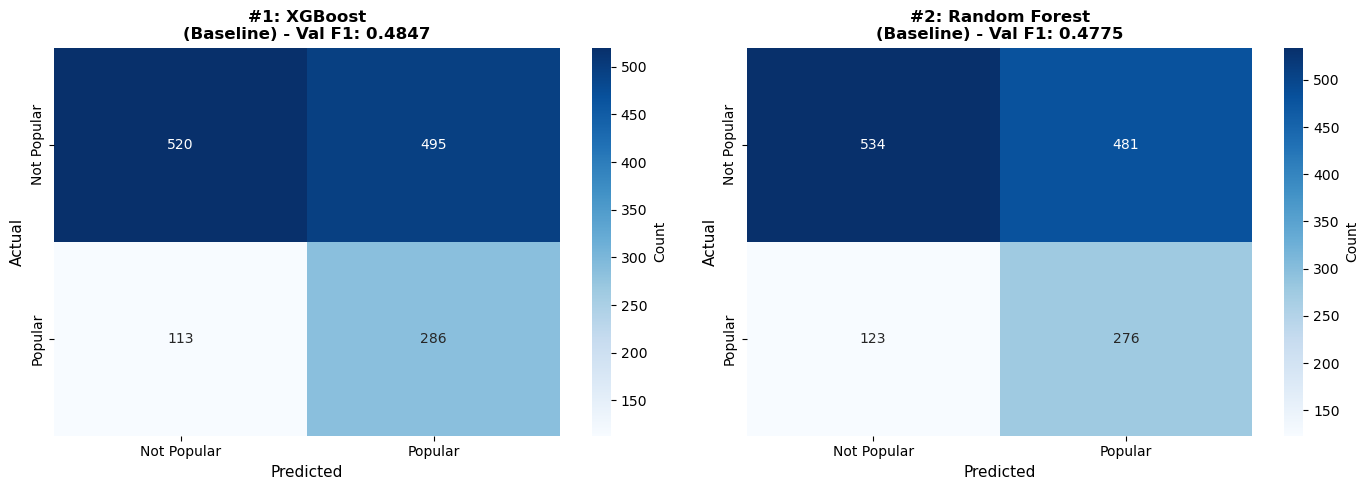


✅ Confusion matrices visualization saved: top_2_models_confusion_matrices.png


In [17]:
# Add this cell after the SMOTE results summary

print("\n" + "=" * 80)
print("DETAILED ANALYSIS: TOP 2 MODELS (SMOTE)")
print("=" * 80)

# Get top 2 models
top_2_models = summary_df_smote_sorted.head(2)

for idx, row in top_2_models.iterrows():
    preprocessing = row['Preprocessing']
    model_name = row['Model']
    
    print(f"\n{'='*80}")
    print(f"MODEL {idx+1}: {model_name} ({preprocessing})")
    print(f"{'='*80}")
    
    # Get the corresponding data
    if preprocessing == 'Baseline':
        X_train_smote = X_train_baseline_smote
        X_val_data = X_val_baseline
        y_train_smote = y_train_baseline_smote
    elif preprocessing == 'L1':
        X_train_smote = X_train_L1_smote
        X_val_data = X_val_L1
        y_train_smote = y_train_L1_smote
    else:  # PCA
        X_train_smote = X_train_pca_smote
        X_val_data = X_val_pca
        y_train_smote = y_train_pca_smote
    
    # Get fresh model and train
    model = get_models()[model_name]
    model.fit(X_train_smote, y_train_smote)
    
    # Predictions
    y_val_pred = model.predict(X_val_data)
    
    # Metrics
    print(f"\n📊 VALIDATION METRICS:")
    print(f"   Accuracy:  {row['Val_Acc']:.4f}")
    print(f"   F1 Score:  {row['Val_F1']:.4f}")
    print(f"   Precision: {row['Val_Precision']:.4f}")
    print(f"   Recall:    {row['Val_Recall']:.4f}")
    if row['Val_ROC_AUC']:
        print(f"   ROC-AUC:   {row['Val_ROC_AUC']:.4f}")
    
    # Classification Report
    print(f"\n📋 CLASSIFICATION REPORT:")
    print(classification_report(y_val_array, y_val_pred, 
                              target_names=['Not Popular (0)', 'Popular (1)'],
                              digits=4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_val_array, y_val_pred)
    print(f"\n📊 CONFUSION MATRIX:")
    print(f"                    Predicted")
    print(f"                Not Popular  Popular")
    print(f"Actual Not Popular    {cm[0,0]:5d}     {cm[0,1]:5d}")
    print(f"       Popular        {cm[1,0]:5d}     {cm[1,1]:5d}")
    
    print(f"\n   True Negatives (TN):  {cm[0,0]:5d} - Correctly predicted Not Popular")
    print(f"   False Positives (FP): {cm[0,1]:5d} - Incorrectly predicted Popular")
    print(f"   False Negatives (FN): {cm[1,0]:5d} - Incorrectly predicted Not Popular")
    print(f"   True Positives (TP):  {cm[1,1]:5d} - Correctly predicted Popular")
    
    # Additional metrics from confusion matrix
    sensitivity = cm[1,1] / (cm[1,0] + cm[1,1])  # True Positive Rate
    specificity = cm[0,0] / (cm[0,0] + cm[0,1])  # True Negative Rate
    
    print(f"\n   Sensitivity (Recall):  {sensitivity:.4f} - % of Popular correctly identified")
    print(f"   Specificity:           {specificity:.4f} - % of Not Popular correctly identified")

# Visualization for top 2 models
print("\n" + "=" * 80)
print("VISUALIZING TOP 2 MODELS")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (idx, row) in enumerate(top_2_models.iterrows()):
    preprocessing = row['Preprocessing']
    model_name = row['Model']
    
    # Get data and retrain
    if preprocessing == 'Baseline':
        X_train_smote = X_train_baseline_smote
        X_val_data = X_val_baseline
        y_train_smote = y_train_baseline_smote
    elif preprocessing == 'L1':
        X_train_smote = X_train_L1_smote
        X_val_data = X_val_L1
        y_train_smote = y_train_L1_smote
    else:
        X_train_smote = X_train_pca_smote
        X_val_data = X_val_pca
        y_train_smote = y_train_pca_smote
    
    model = get_models()[model_name]
    model.fit(X_train_smote, y_train_smote)
    y_val_pred = model.predict(X_val_data)
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_val_array, y_val_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
               xticklabels=['Not Popular', 'Popular'],
               yticklabels=['Not Popular', 'Popular'],
               cbar_kws={'label': 'Count'})
    
    axes[i].set_xlabel('Predicted', fontsize=11)
    axes[i].set_ylabel('Actual', fontsize=11)
    axes[i].set_title(f'#{i+1}: {model_name}\n({preprocessing}) - Val F1: {row["Val_F1"]:.4f}',
                     fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('top_2_models_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Confusion matrices visualization saved: top_2_models_confusion_matrices.png")
print("=" * 80)

CORRELATION-BASED FEATURE SELECTION

🔍 Analyzing correlations with target variable...

📊 Threshold: 0.05
   Features selected: 8
   Features: ['artist_avg_rank', 'artist_best_rank', 'artist_song_count', 'is_friday_release', 'Speechiness', 'Danceability', 'Valence', 'Loudness_norm']

📊 Threshold: 0.1
   Features selected: 2
   Features: ['artist_avg_rank', 'artist_best_rank']

📊 Threshold: 0.15
   Features selected: 2
   Features: ['artist_avg_rank', 'artist_best_rank']

📊 Threshold: 0.2
   Features selected: 2
   Features: ['artist_avg_rank', 'artist_best_rank']

VISUALIZING FEATURE CORRELATIONS


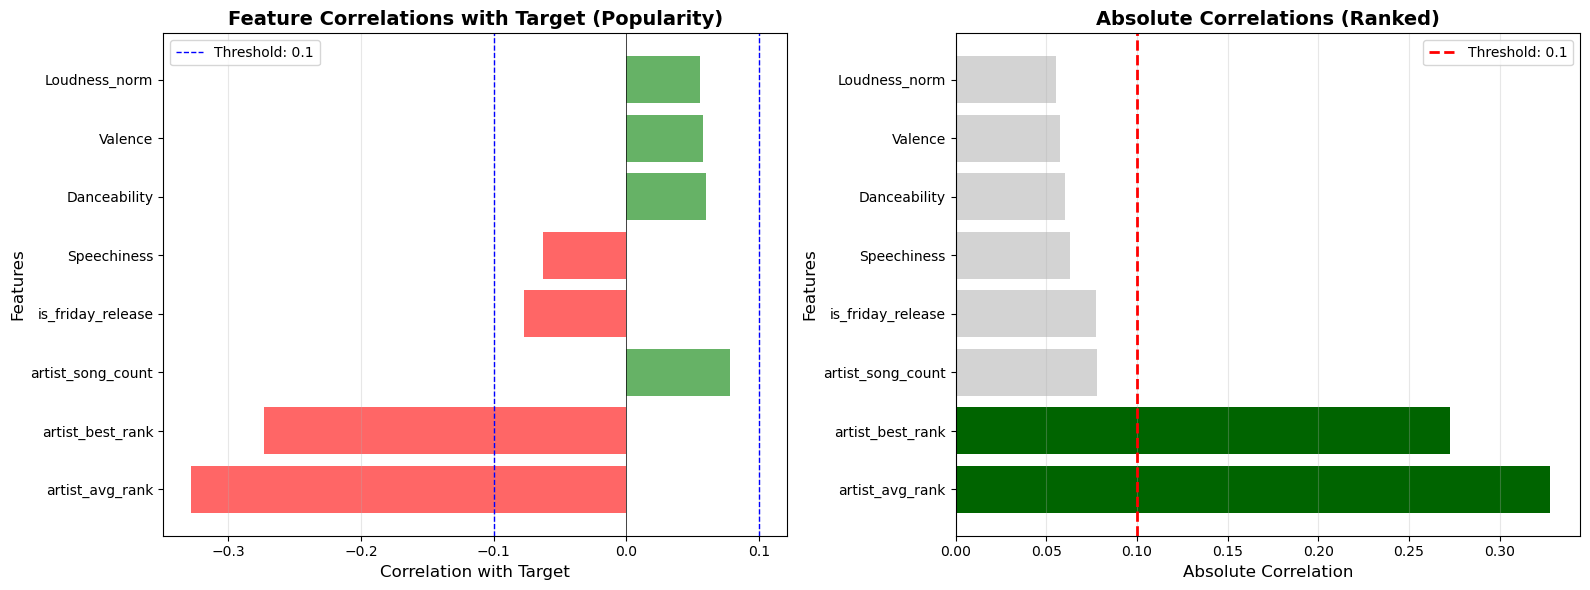


✅ Correlation visualization saved: feature_correlations_analysis.png

CREATING CORRELATION-FILTERED DATASETS

📋 Selected 2 features with correlation >= 0.1:
         Feature  Correlation       P_Value
 artist_avg_rank    -0.327947 2.451792e-154
artist_best_rank    -0.272917 1.259423e-105

✅ Correlation-filtered datasets created:
   X_train_corr: (6158, 2)
   X_val_corr: (1414, 2)

✅ SMOTE applied to correlation-filtered data:
   X_train_corr_smote: (8620, 2)
   Class distribution: [4310 4310]

✅ CORRELATION-BASED FEATURE SELECTION COMPLETE!


In [18]:
# ============================================================================
# CORRELATION-BASED FEATURE SELECTION
# ============================================================================

print("=" * 80)
print("CORRELATION-BASED FEATURE SELECTION")
print("=" * 80)

def select_features_by_correlation(X_train, y_train, threshold=0.1, method='pearson'):
    """
    Select features based on correlation with target variable.
    
    Parameters:
    -----------
    X_train : DataFrame
        Training features
    y_train : array-like
        Training target
    threshold : float
        Minimum absolute correlation to keep feature
    method : str
        Correlation method ('pearson', 'spearman', or 'kendall')
    
    Returns:
    --------
    selected_features : list
        List of selected feature names
    correlations : DataFrame
        DataFrame with correlation values
    """
    # Calculate correlations with target
    correlations = []
    
    for col in X_train.columns:
        if method == 'pearson':
            corr, p_value = stats.pearsonr(X_train[col], y_train)
        elif method == 'spearman':
            corr, p_value = stats.spearmanr(X_train[col], y_train)
        elif method == 'kendall':
            corr, p_value = stats.kendalltau(X_train[col], y_train)
        
        correlations.append({
            'Feature': col,
            'Correlation': corr,
            'Abs_Correlation': abs(corr),
            'P_Value': p_value,
            'Significant': p_value < 0.05
        })
    
    corr_df = pd.DataFrame(correlations)
    corr_df = corr_df.sort_values('Abs_Correlation', ascending=False)
    
    # Select features above threshold
    selected_features = corr_df[corr_df['Abs_Correlation'] >= threshold]['Feature'].tolist()
    
    return selected_features, corr_df

# ============================================================================
# APPLY CORRELATION SELECTION TO BASELINE DATA
# ============================================================================

print("\n🔍 Analyzing correlations with target variable...")

# Try different correlation thresholds
thresholds = [0.05, 0.10, 0.15, 0.20]
correlation_results = {}

for threshold in thresholds:
    selected_features, corr_df = select_features_by_correlation(
        X_train_baseline, 
        y_train_array, 
        threshold=threshold,
        method='pearson'
    )
    
    correlation_results[threshold] = {
        'features': selected_features,
        'corr_df': corr_df,
        'n_features': len(selected_features)
    }
    
    print(f"\n📊 Threshold: {threshold}")
    print(f"   Features selected: {len(selected_features)}")
    print(f"   Features: {selected_features}")

# ============================================================================
# VISUALIZE CORRELATIONS
# ============================================================================

print("\n" + "=" * 80)
print("VISUALIZING FEATURE CORRELATIONS")
print("=" * 80)

# Get correlation data for default threshold (0.1)
corr_df = correlation_results[0.10]['corr_df']

# Plot correlation values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar plot of correlations
ax1 = axes[0]
colors = ['green' if x > 0 else 'red' for x in corr_df['Correlation']]
ax1.barh(corr_df['Feature'], corr_df['Correlation'], color=colors, alpha=0.6)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax1.axvline(x=0.1, color='blue', linestyle='--', linewidth=1, label='Threshold: 0.1')
ax1.axvline(x=-0.1, color='blue', linestyle='--', linewidth=1)
ax1.set_xlabel('Correlation with Target', fontsize=12)
ax1.set_ylabel('Features', fontsize=12)
ax1.set_title('Feature Correlations with Target (Popularity)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Absolute correlations with threshold lines
ax2 = axes[1]
ax2.barh(corr_df['Feature'], corr_df['Abs_Correlation'], 
         color=['darkgreen' if x >= 0.1 else 'lightgray' for x in corr_df['Abs_Correlation']])
ax2.axvline(x=0.1, color='red', linestyle='--', linewidth=2, label='Threshold: 0.1')
ax2.set_xlabel('Absolute Correlation', fontsize=12)
ax2.set_ylabel('Features', fontsize=12)
ax2.set_title('Absolute Correlations (Ranked)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_correlations_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Correlation visualization saved: feature_correlations_analysis.png")

# ============================================================================
# CREATE CORRELATION-FILTERED DATASETS
# ============================================================================

print("\n" + "=" * 80)
print("CREATING CORRELATION-FILTERED DATASETS")
print("=" * 80)

# Use threshold = 0.1 as default
selected_features_corr = correlation_results[0.10]['features']

print(f"\n📋 Selected {len(selected_features_corr)} features with correlation >= 0.1:")
print(corr_df[corr_df['Abs_Correlation'] >= 0.1][['Feature', 'Correlation', 'P_Value']].to_string(index=False))

# Create filtered datasets
X_train_corr = X_train_baseline[selected_features_corr]
X_val_corr = X_val_baseline[selected_features_corr]

print(f"\n✅ Correlation-filtered datasets created:")
print(f"   X_train_corr: {X_train_corr.shape}")
print(f"   X_val_corr: {X_val_corr.shape}")

# Apply SMOTE to correlation-filtered data
X_train_corr_smote, y_train_corr_smote = smote.fit_resample(X_train_corr, y_train_array)
print(f"\n✅ SMOTE applied to correlation-filtered data:")
print(f"   X_train_corr_smote: {X_train_corr_smote.shape}")
print(f"   Class distribution: {np.bincount(y_train_corr_smote)}")

# Add to datasets dictionary
datasets_smote['Correlation'] = (X_train_corr_smote, X_val_corr, y_train_corr_smote)

print("\n" + "=" * 80)
print("✅ CORRELATION-BASED FEATURE SELECTION COMPLETE!")
print("=" * 80)